# 2. Μοντελοποίηση και Πρόβλεψη Τιμής  
## (Price Prediction Modeling)

Στο παρόν notebook υλοποιείται το στάδιο της **προγνωστικής μοντελοποίησης** για την εκτίμηση της τιμής μεταχειρισμένων αυτοκινήτων στην Αττική.

Η ανάλυση βασίζεται στο αρχείο `ml_ready_car_data.csv`, το οποίο έχει ήδη παραχθεί από το προηγούμενο στάδιο καθαρισμού και προετοιμασίας δεδομένων.

### Στόχοι του notebook
- φόρτωση του **model-ready dataset**
- επιλογή του κατάλληλου υποσυνόλου για modeling
- ορισμός μεταβλητών εισόδου (*predictors*) και μεταβλητής-στόχου (*target*)
- δημιουργία reproducible preprocessing pipeline
- εκπαίδευση και σύγκριση πολλαπλών μοντέλων παλινδρόμησης
- αξιολόγηση με **MAE**, **RMSE** και **R²**
- ανάλυση του καλύτερου μοντέλου με διαγνωστικά γραφήματα και feature importance

## Μεθοδολογικό Πλαίσιο Μοντελοποίησης

Η ροή της ανάλυσης ακολουθεί τα εξής στάδια:

1. **Φόρτωση** του `ml_ready_car_data.csv`
2. **Περιορισμός** της ανάλυσης στο υποσύνολο των μεταχειρισμένων οχημάτων
3. **Ορισμός** target και predictors
4. **Διαχωρισμός** σε train και test σύνολο
5. **Preprocessing** με imputation, scaling και one-hot encoding
6. **Εκπαίδευση** baseline και ισχυρότερων μοντέλων
7. **Σύγκριση** της απόδοσης των μοντέλων
8. **Διαγνωστικός έλεγχος** του καλύτερου μοντέλου
9. **Προαιρετική δοκιμή** λογαριθμικού μετασχηματισμού της τιμής

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# ============================================================
# ΒΑΣΙΚΕΣ ΡΥΘΜΙΣΕΙΣ
# ============================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42


def resolve_data_path(filename: str) -> Path:
    """
    Εντοπίζει το αρχείο δεδομένων είτε μέσα στο project
    είτε στο προσωρινό περιβάλλον εκτέλεσης.
    """
    candidate_paths = [
        Path.cwd() / "data" / "processed" / filename,
        Path.cwd().parent / "data" / "processed" / filename,
        Path("/mnt/data") / filename,
        Path("/mnt/data") / "data" / "processed" / filename,
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    raise FileNotFoundError(f"Δεν βρέθηκε το αρχείο: {filename}")


def regression_metrics(y_true, y_pred):
    """
    Υπολογισμός βασικών μετρικών παλινδρόμησης.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

## Φόρτωση του Model-Ready Dataset

Στο σημείο αυτό φορτώνεται το αρχείο `ml_ready_car_data.csv`, το οποίο αποτελεί το τελικό σύνολο δεδομένων για το στάδιο της μοντελοποίησης.

Αρχικά εξετάζονται:
- οι διαστάσεις του dataset,
- οι μεταβλητές,
- οι τύποι δεδομένων,
- και η ύπαρξη ελλειπουσών τιμών.

In [3]:
# ============================================================
# ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ
# ============================================================

data_path = resolve_data_path("ml_ready_car_data.csv")
df = pd.read_csv(data_path)

print("Data path:", data_path)
print("Shape:", df.shape)
print("\nΣτήλες:")
print(df.columns.tolist())

print("\nΤύποι δεδομένων:")
display(df.dtypes)

print("\nΠρώτες 5 εγγραφές:")
display(df.head())

print("\nMissing values ανά στήλη:")
display(df.isna().sum().to_frame(name="missing_count"))

Data path: c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\ml_ready_car_data.csv
Shape: (8933, 12)

Στήλες:
['Κατασκευαστής', 'Τύπος', 'Εγγραφή', 'Ηλικία', 'Καύσιμο', 'Μετάδοση', 'Κυβικά', 'Ιπποδύναμη', 'Χιλιόμετρα', 'Κατάσταση', 'Περιοχή', 'Τιμή']

Τύποι δεδομένων:


Κατασκευαστής        str
Τύπος                str
Εγγραφή          float64
Ηλικία           float64
Καύσιμο              str
Μετάδοση             str
Κυβικά           float64
Ιπποδύναμη       float64
Χιλιόμετρα       float64
Κατάσταση            str
Περιοχή              str
Τιμή             float64
dtype: object


Πρώτες 5 εγγραφές:


,Κατασκευαστής,Τύπος,Εγγραφή,Ηλικία,Καύσιμο,Μετάδοση,Κυβικά,Ιπποδύναμη,Χιλιόμετρα,Κατάσταση,Περιοχή,Τιμή
0,Audi,Q3,"2,025.00",1.00,Βενζίνη,Αυτόματο,"1,500.00",150.00,"10,500.00",Μεταχειρισμένο,ΚΗΦΙΣΙΑ 14561,"34,900.00"
1,Toyota,Yaris Cross,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,500.00",116.00,"10,018.00",Μεταχειρισμένο,ΝΕΑ ΙΩΝΙΑ 14235,"25,990.00"
2,Peugeot,2008,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,200.00",145.00,"3,000.00",Μεταχειρισμένο,ΚΗΦΙΣΙΑ 14562,"26,500.00"
3,Peugeot,2008,"2,025.00",1.00,Υβριδικό Βενζίνης,Αυτόματο,"1,200.00",145.00,"2,900.00",Μεταχειρισμένο,ΝΕΑ ΕΡΥΘΡΑΙA 14671,"26,500.00"
4,Beev,ΒEEV-6,"2,025.00",1.00,Ηλεκτρικό,Αυτόματο,NaN,4.00,0.00,Καινούργιο,ΓΛΥΚΑ ΝΕΡΑ 15354,"10,900.00"



Missing values ανά στήλη:


,missing_count
Κατασκευαστής,0
Τύπος,0
Εγγραφή,0
Ηλικία,0
Καύσιμο,0
Μετάδοση,0
Κυβικά,769
Ιπποδύναμη,0
Χιλιόμετρα,2
Κατάσταση,0


## Επιλογή Αναλυτικού Υποσυνόλου και Μεταβλητών

Παρότι το συνολικό dataset περιλαμβάνει καινούργια και leasing οχήματα, η παρούσα μελέτη εστιάζει στην **αγορά μεταχειρισμένων αυτοκινήτων**.  
Για τον λόγο αυτό, το κύριο μοντέλο θα εκπαιδευτεί μόνο στο υποσύνολο των παρατηρήσεων με `Κατάσταση = Μεταχειρισμένο`.

Επιπλέον:
- η μεταβλητή **Τιμή** ορίζεται ως μεταβλητή-στόχος,
- η μεταβλητή **Κατάσταση** αφαιρείται από τα predictors, επειδή στο used-only subset είναι σταθερή,
- η μεταβλητή **Εγγραφή** αφαιρείται ώστε να αποφευχθεί πλεονασμός με τη μεταβλητή **Ηλικία**.

In [4]:
# ============================================================
# USED-ONLY SUBSET ΓΙΑ ΤΟ ΚΥΡΙΟ MODELING
# ============================================================

print("Κατανομή μεταβλητής 'Κατάσταση':")
display(
    df["Κατάσταση"]
    .value_counts(dropna=False)
    .rename_axis("Κατάσταση")
    .reset_index(name="Πλήθος")
)

# Κρατάμε μόνο μεταχειρισμένα οχήματα
df_model = df[df["Κατάσταση"] == "Μεταχειρισμένο"].copy()

print("\nShape used-only dataset:", df_model.shape)

# Στήλες που δεν θα χρησιμοποιηθούν ως predictors
features_to_drop = ["Τιμή", "Κατάσταση", "Εγγραφή"]

# Ορισμός predictors και target
X = df_model.drop(columns=features_to_drop)
y = df_model["Τιμή"].copy()

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget variable:")
print("Τιμή")

print("\nMissing values μόνο στις μεταβλητές modeling:")
display(X.isna().sum().to_frame(name="missing_count"))

print("\nΠεριγραφικά στατιστικά της τιμής:")
display(y.describe().to_frame(name="Τιμή"))

Κατανομή μεταβλητής 'Κατάσταση':


,Κατάσταση,Πλήθος
0,Μεταχειρισμένο,8296
1,Καινούργιο,623
2,Leasing,14



Shape used-only dataset: (8296, 12)

Predictor columns:
['Κατασκευαστής', 'Τύπος', 'Ηλικία', 'Καύσιμο', 'Μετάδοση', 'Κυβικά', 'Ιπποδύναμη', 'Χιλιόμετρα', 'Περιοχή']

Target variable:
Τιμή

Missing values μόνο στις μεταβλητές modeling:


,missing_count
Κατασκευαστής,0
Τύπος,0
Ηλικία,0
Καύσιμο,0
Μετάδοση,0
Κυβικά,652
Ιπποδύναμη,0
Χιλιόμετρα,2
Περιοχή,0



Περιγραφικά στατιστικά της τιμής:


,Τιμή
count,"8,296.00"
mean,"33,280.20"
std,"34,021.78"
min,"2,000.00"
25%,"16,700.00"
50%,"22,000.00"
75%,"35,000.00"
max,"550,000.00"


## Διαχωρισμός Δεδομένων και Preprocessing Pipeline

Για να διασφαλιστεί η σωστή αξιολόγηση των μοντέλων, το dataset χωρίζεται σε:
- **train set** για εκπαίδευση
- **test set** για τελική αξιολόγηση

Στο preprocessing εφαρμόζονται:
- **median imputation** στις αριθμητικές μεταβλητές
- **most frequent imputation** στις κατηγορικές μεταβλητές
- **scaling** στις αριθμητικές μεταβλητές
- **one-hot encoding** στις κατηγορικές μεταβλητές

In [5]:
# ============================================================
# TRAIN / TEST SPLIT ΚΑΙ PREPROCESSING
# ============================================================

# Διαχωρισμός αριθμητικών και κατηγορικών μεταβλητών
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Αριθμητικές μεταβλητές:")
print(numeric_features)

print("\nΚατηγορικές μεταβλητές:")
print(categorical_features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("\nShapes μετά το split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Συμβατότητα μεταξύ διαφορετικών εκδόσεων scikit-learn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Pipeline για αριθμητικές μεταβλητές
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline για κατηγορικές μεταβλητές
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", ohe)
])

# Ενιαίο preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

Αριθμητικές μεταβλητές:
['Ηλικία', 'Κυβικά', 'Ιπποδύναμη', 'Χιλιόμετρα']

Κατηγορικές μεταβλητές:
['Κατασκευαστής', 'Τύπος', 'Καύσιμο', 'Μετάδοση', 'Περιοχή']

Shapes μετά το split:
X_train: (6636, 9)
X_test : (1660, 9)
y_train: (6636,)
y_test : (1660,)


## Ορισμός Υποψήφιων Μοντέλων

Στο παρόν στάδιο συγκρίνονται τα ακόλουθα μοντέλα:

### Baseline models
- `DummyRegressor`
- `LinearRegression`
- `Ridge`

### Πιο ισχυρά μοντέλα
- `RandomForestRegressor`
- `XGBRegressor` (εφόσον είναι διαθέσιμο το XGBoost στο περιβάλλον)

Η σύγκριση baseline και πιο σύνθετων μοντέλων είναι απαραίτητη ώστε να τεκμηριωθεί αν η αυξημένη πολυπλοκότητα οδηγεί πράγματι σε καλύτερη προγνωστική απόδοση.

In [6]:
# ============================================================
# ΟΡΙΣΜΟΣ ΜΟΝΤΕΛΩΝ
# ============================================================

models = {
    "DummyRegressor": DummyRegressor(strategy="median"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

# Προαιρετική προσθήκη XGBoost
xgb_available = False

try:
    from xgboost import XGBRegressor

    models["XGBoost"] = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_available = True
    print("Το XGBoost φορτώθηκε επιτυχώς.")
except Exception as e:
    print("Το XGBoost δεν είναι διαθέσιμο στο τρέχον περιβάλλον.")
    print("Συνέχεια χωρίς XGBoost.")
    print("Λεπτομέρεια:", e)

print("\nΜοντέλα που θα αξιολογηθούν:")
print(list(models.keys()))

Το XGBoost φορτώθηκε επιτυχώς.

Μοντέλα που θα αξιολογηθούν:
['DummyRegressor', 'LinearRegression', 'Ridge', 'RandomForest', 'XGBoost']


## Εκπαίδευση και Αξιολόγηση Μοντέλων

Κάθε μοντέλο θα ενσωματωθεί σε ενιαίο pipeline μαζί με το preprocessing, ώστε:
- να αποφεύγεται data leakage,
- να υπάρχει πλήρης αναπαραγωγιμότητα της διαδικασίας,
- και να συγκρίνονται όλα τα μοντέλα κάτω από τις ίδιες συνθήκες.

In [7]:
# ============================================================
# ΕΚΠΑΙΔΕΥΣΗ ΚΑΙ ΑΞΙΟΛΟΓΗΣΗ
# ============================================================

results = []
trained_models = {}
model_templates = {}
predictions = {}

for model_name, model in models.items():
    print(f"Εκπαίδευση μοντέλου: {model_name}")

    # Δημιουργία pipeline
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Κρατάμε unfitted template για μελλοντική χρήση (π.χ. log-target)
    model_templates[model_name] = clone(pipe)

    # Εκπαίδευση
    pipe.fit(X_train, y_train)

    # Πρόβλεψη
    y_pred = pipe.predict(X_test)

    # Μετρικές
    metrics = regression_metrics(y_test, y_pred)

    results.append({
        "Μοντέλο": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })

    trained_models[model_name] = pipe
    predictions[model_name] = y_pred

# Συγκεντρωτικός πίνακας αποτελεσμάτων
results_df = pd.DataFrame(results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)

print("\nΑποτελέσματα μοντέλων (ταξινόμηση με βάση το RMSE):")
display(results_df)

Εκπαίδευση μοντέλου: DummyRegressor
Εκπαίδευση μοντέλου: LinearRegression
Εκπαίδευση μοντέλου: Ridge
Εκπαίδευση μοντέλου: RandomForest
Εκπαίδευση μοντέλου: XGBoost

Αποτελέσματα μοντέλων (ταξινόμηση με βάση το RMSE):


,Μοντέλο,MAE,RMSE,R2
0,XGBoost,"4,089.66","7,587.25",0.94
1,RandomForest,"3,855.42","8,159.86",0.93
2,Ridge,"5,670.67","9,988.70",0.90
3,LinearRegression,"5,301.68","10,312.95",0.89
4,DummyRegressor,"16,831.92","33,345.89",-0.13


## Επιλογή Καλύτερου Μοντέλου

Το καλύτερο μοντέλο θα επιλεγεί με κύριο κριτήριο το **χαμηλότερο RMSE**, ενώ θα συνεκτιμώνται και τα **MAE** και **R²**.

Στη συνέχεια θα παρουσιαστούν:
- γράφημα **πραγματικών έναντι προβλεπόμενων τιμών**
- γράφημα **υπολοίπων**
- κατανομή των υπολοίπων

Καλύτερο μοντέλο: XGBoost


,Μοντέλο,MAE,RMSE,R2
0,XGBoost,"4,089.66","7,587.25",0.94


,Actual_Price,Predicted_Price,Residual
0,"90,000.00","60,678.30","29,321.70"
1,"11,900.00","13,393.32","-1,493.32"
2,"22,500.00","20,594.51","1,905.49"
3,"25,550.00","28,773.64","-3,223.64"
4,"12,900.00","12,168.12",731.88
5,"27,500.00","27,818.15",-318.15
6,"7,000.00","8,011.45","-1,011.45"
7,"19,980.00","17,283.49","2,696.51"
8,"13,200.00","13,343.91",-143.91
9,"27,000.00","26,750.95",249.05


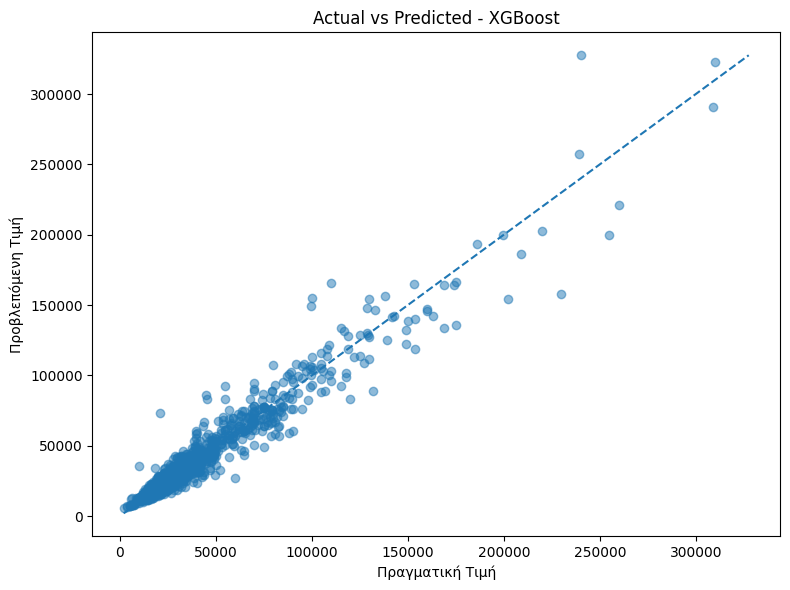

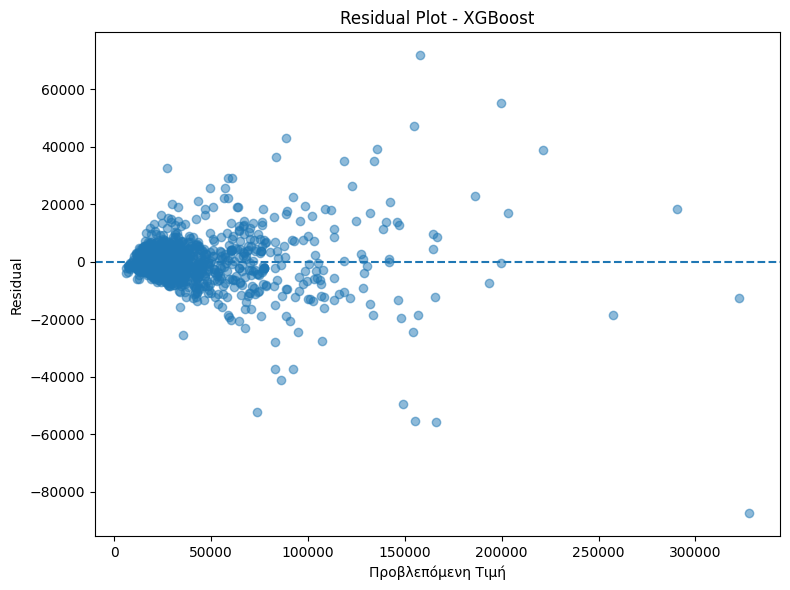

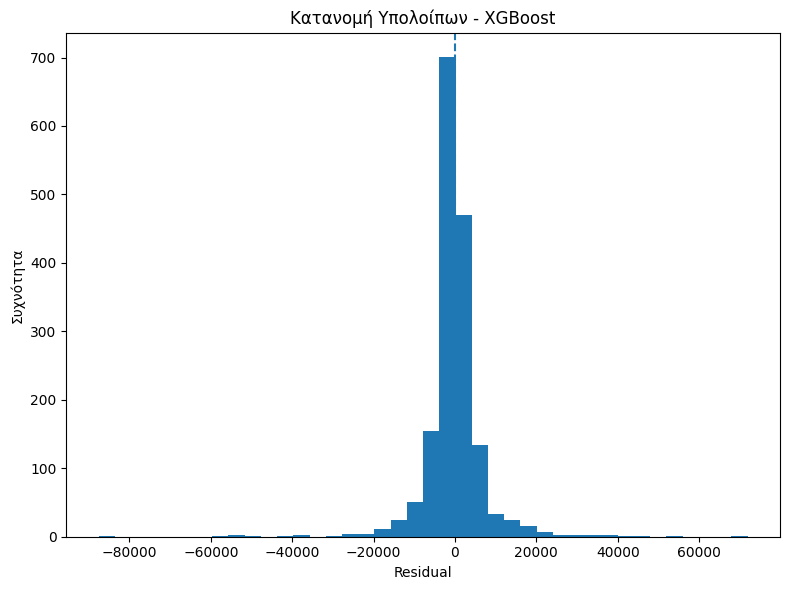

In [8]:
# ============================================================
# ΕΠΙΛΟΓΗ ΚΑΛΥΤΕΡΟΥ ΜΟΝΤΕΛΟΥ ΚΑΙ ΔΙΑΓΝΩΣΤΙΚΑ ΓΡΑΦΗΜΑΤΑ
# ============================================================

best_model_name = results_df.iloc[0]["Μοντέλο"]
best_pipeline = trained_models[best_model_name]
best_y_pred = predictions[best_model_name]

print("Καλύτερο μοντέλο:", best_model_name)
display(results_df.head(1))

# Πίνακας πραγματικών και προβλεπόμενων τιμών
comparison_df = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": best_y_pred
})
comparison_df["Residual"] = comparison_df["Actual_Price"] - comparison_df["Predicted_Price"]

display(comparison_df.head(10))

# ----------------------------------------
# 1. Actual vs Predicted
# ----------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(comparison_df["Actual_Price"], comparison_df["Predicted_Price"], alpha=0.5)

min_val = min(comparison_df["Actual_Price"].min(), comparison_df["Predicted_Price"].min())
max_val = max(comparison_df["Actual_Price"].max(), comparison_df["Predicted_Price"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Πραγματική Τιμή")
plt.ylabel("Προβλεπόμενη Τιμή")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2. Residual plot
# ----------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(comparison_df["Predicted_Price"], comparison_df["Residual"], alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Προβλεπόμενη Τιμή")
plt.ylabel("Residual")
plt.title(f"Residual Plot - {best_model_name}")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 3. Κατανομή υπολοίπων
# ----------------------------------------
plt.figure(figsize=(8, 6))
plt.hist(comparison_df["Residual"], bins=40)
plt.axvline(x=0, linestyle="--")
plt.xlabel("Residual")
plt.ylabel("Συχνότητα")
plt.title(f"Κατανομή Υπολοίπων - {best_model_name}")
plt.tight_layout()
plt.show()

## Feature Importance / Συνεισφορά Μεταβλητών

Η ερμηνεία του καλύτερου μοντέλου είναι σημαντική για την ακαδημαϊκή τεκμηρίωση της μελέτης.

Εάν το μοντέλο υποστηρίζει:
- `feature_importances_`, θα παρουσιαστούν οι σημαντικότερες μεταβλητές,
- `coef_`, θα παρουσιαστούν τα απόλυτα μεγέθη των συντελεστών.

Με αυτόν τον τρόπο εντοπίζονται τα χαρακτηριστικά που συνδέονται περισσότερο με τη διαμόρφωση της τιμής.

Top 20 σημαντικότερες μεταβλητές για το μοντέλο: XGBoost


,feature,feature_importance
1,num__Κυβικά,0.16
583,cat__Καύσιμο_Ηλεκτρικό,0.08
2,num__Ιπποδύναμη,0.05
372,cat__Τύπος_M5,0.04
41,cat__Κατασκευαστής_Lamborghini,0.03
582,cat__Καύσιμο_Βενζίνη,0.02
200,cat__Τύπος_Cayman,0.02
58,cat__Κατασκευαστής_Porsche,0.02
589,cat__Μετάδοση_Χειροκίνητο,0.02
65,cat__Κατασκευαστής_Tesla,0.02


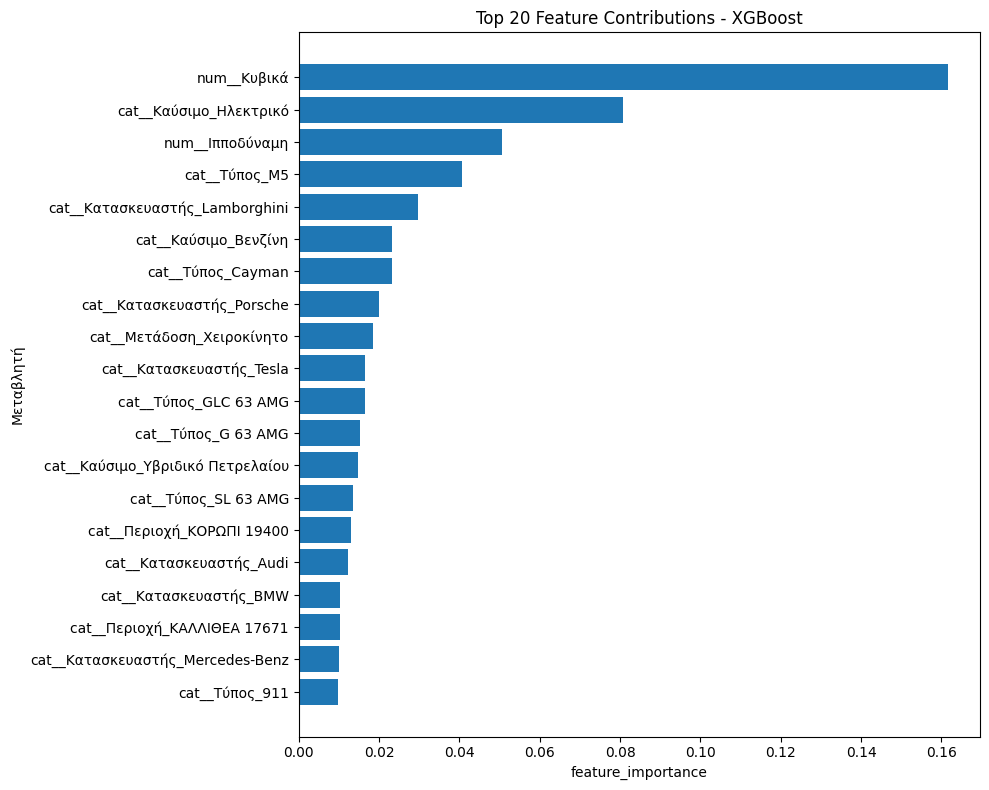

In [9]:
# ============================================================
# FEATURE IMPORTANCE / COEFFICIENT ANALYSIS
# ============================================================

def get_feature_contributions(fitted_pipeline, top_n=20):
    """
    Επιστρέφει πίνακα σημαντικότητας μεταβλητών ή απόλυτων συντελεστών,
    ανάλογα με τον τύπο του μοντέλου.
    """
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    fitted_model = fitted_pipeline.named_steps["model"]

    feature_names = fitted_preprocessor.get_feature_names_out()

    if hasattr(fitted_model, "feature_importances_"):
        contribution_values = fitted_model.feature_importances_
        contribution_name = "feature_importance"

    elif hasattr(fitted_model, "coef_"):
        contribution_values = np.abs(np.ravel(fitted_model.coef_))
        contribution_name = "abs_coefficient"

    else:
        return None

    contribution_df = pd.DataFrame({
        "feature": feature_names,
        contribution_name: contribution_values
    }).sort_values(by=contribution_name, ascending=False).head(top_n)

    return contribution_df, contribution_name


feature_output = get_feature_contributions(best_pipeline, top_n=20)

if feature_output is None:
    print(f"Το μοντέλο {best_model_name} δεν παρέχει εύκολα ερμηνεύσιμη σημαντικότητα μεταβλητών.")
else:
    importance_df, importance_col = feature_output

    print(f"Top 20 σημαντικότερες μεταβλητές για το μοντέλο: {best_model_name}")
    display(importance_df)

    plot_df = importance_df.sort_values(by=importance_col, ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(plot_df["feature"], plot_df[importance_col])
    plt.xlabel(importance_col)
    plt.ylabel("Μεταβλητή")
    plt.title(f"Top 20 Feature Contributions - {best_model_name}")
    plt.tight_layout()
    plt.show()

## Προαιρετική Δοκιμή: Λογαριθμικός Μετασχηματισμός της Τιμής

Επειδή η μεταβλητή **Τιμή** εμφανίζει έντονη δεξιά ασυμμετρία, εξετάζεται προαιρετικά και μια εναλλακτική προσέγγιση, όπου το μοντέλο εκπαιδεύεται πάνω στο `log(Τιμή + 1)`.

Η διαδικασία αυτή εφαρμόζεται μόνο στο **καλύτερο μοντέλο** της προηγούμενης σύγκρισης, ώστε να ελεγχθεί αν ο λογαριθμικός μετασχηματισμός βελτιώνει την προγνωστική ακρίβεια.

In [10]:
# ============================================================
# ΠΡΟΑΙΡΕΤΙΚΗ ΣΥΓΚΡΙΣΗ RAW TARGET vs LOG TARGET
# ============================================================

best_template = clone(model_templates[best_model_name])

log_target_model = TransformedTargetRegressor(
    regressor=best_template,
    func=np.log1p,
    inverse_func=np.expm1
)

print(f"Εκπαίδευση {best_model_name} με log-transformed target...")
log_target_model.fit(X_train, y_train)

log_y_pred = log_target_model.predict(X_test)

raw_metrics = results_df[results_df["Μοντέλο"] == best_model_name][["MAE", "RMSE", "R2"]].iloc[0].to_dict()
log_metrics = regression_metrics(y_test, log_y_pred)

log_comparison_df = pd.DataFrame([
    {
        "Εκδοχή target": "Raw Price",
        "MAE": raw_metrics["MAE"],
        "RMSE": raw_metrics["RMSE"],
        "R2": raw_metrics["R2"]
    },
    {
        "Εκδοχή target": "Log Price",
        "MAE": log_metrics["MAE"],
        "RMSE": log_metrics["RMSE"],
        "R2": log_metrics["R2"]
    }
]).sort_values(by="RMSE", ascending=True).reset_index(drop=True)

print("Σύγκριση καλύτερου μοντέλου με raw και log target:")
display(log_comparison_df)

Εκπαίδευση XGBoost με log-transformed target...
Σύγκριση καλύτερου μοντέλου με raw και log target:


,Εκδοχή target,MAE,RMSE,R2
0,Raw Price,"4,089.66","7,587.25",0.94
1,Log Price,"3,956.60","7,814.73",0.94


## Εξαγωγή Αποτελεσμάτων

Για λόγους αναπαραγωγιμότητας και τεκμηρίωσης, αποθηκεύονται:
- ο συγκεντρωτικός πίνακας αποτελεσμάτων των μοντέλων
- οι προβλέψεις του καλύτερου μοντέλου στο test set

Τα αρχεία αυτά μπορούν να χρησιμοποιηθούν:
- στο επόμενο notebook για περαιτέρω ανάλυση,
- στη συγγραφή της πτυχιακής,
- και σε πίνακες/παραρτήματα τελικής τεκμηρίωσης.

In [11]:
# ============================================================
# ΑΠΟΘΗΚΕΥΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
# ============================================================

# Δημιουργία φακέλου αποθήκευσης αν δεν υπάρχει
output_dir = Path.cwd().parent / "data" / "processed" if (Path.cwd().name == "notebooks") else Path.cwd() / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

# Αποθήκευση συγκριτικών αποτελεσμάτων
results_output_path = output_dir / "model_comparison_results.csv"
results_df.to_csv(results_output_path, index=False, encoding="utf-8-sig")

# Αποθήκευση προβλέψεων καλύτερου μοντέλου
best_predictions_df = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": best_y_pred,
    "Residual": y_test.values - best_y_pred
})

predictions_output_path = output_dir / "best_model_test_predictions.csv"
best_predictions_df.to_csv(predictions_output_path, index=False, encoding="utf-8-sig")

print("Αποθηκεύτηκαν τα εξής αρχεία:")
print("-", results_output_path)
print("-", predictions_output_path)

Αποθηκεύτηκαν τα εξής αρχεία:
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\model_comparison_results.csv
- c:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\processed\best_model_test_predictions.csv


## Συμπεράσματα του Notebook

Με την ολοκλήρωση του παρόντος notebook επιτυγχάνονται τα εξής:

- δημιουργήθηκε πλήρες **modeling pipeline**
- συγκρίθηκαν baseline και πιο σύνθετα μοντέλα
- επιλέχθηκε το καλύτερο μοντέλο με βάση την απόδοση στο test set
- πραγματοποιήθηκε πρώτη ερμηνεία των αποτελεσμάτων
- δημιουργήθηκαν αρχεία εξόδου για τεκμηρίωση και περαιτέρω ανάλυση

### Επόμενο στάδιο
Το επόμενο notebook μπορεί να εστιάσει σε:
- **hyperparameter tuning** των καλύτερων μοντέλων
- **error analysis**
- **SHAP / interpretability**
- τελική σύγκριση και επιλογή του μοντέλου που θα παρουσιαστεί στην πτυχιακή